In [106]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import warnings

# Suppress warnings for a cleaner console output
warnings.filterwarnings('ignore')

In [107]:
df = pd.read_csv('tested.csv')

df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [108]:

print("Missing Values Check ---")
df.isnull().sum()


Missing Values Check ---


PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64

In [109]:
# 2. Print Numerical Survival Rates

print("🔢 SURVIVAL RATES BY CATEGORY (in %)")

print("\n--- By Sex ---")

survival_by_sex = df.groupby('Sex')['Survived'].mean() * 100
print(survival_by_sex.round(2).astype(str) + '%')

print("\n--- By Passenger Class (Pclass) ---")
survival_by_pclass = df.groupby('Pclass')['Survived'].mean() * 100
print(survival_by_pclass.round(2).astype(str) + '%')

print("\n--- By Embarkation Port (Embarked) ---")
survival_by_embarked = df.groupby('Embarked')['Survived'].mean() * 100
print(survival_by_embarked.round(2).astype(str) + '%')

🔢 SURVIVAL RATES BY CATEGORY (in %)

--- By Sex ---
Sex
female    100.0%
male        0.0%
Name: Survived, dtype: object

--- By Passenger Class (Pclass) ---
Pclass
1    46.73%
2    32.26%
3    33.03%
Name: Survived, dtype: object

--- By Embarkation Port (Embarked) ---
Embarked
C    39.22%
Q    52.17%
S    32.59%
Name: Survived, dtype: object


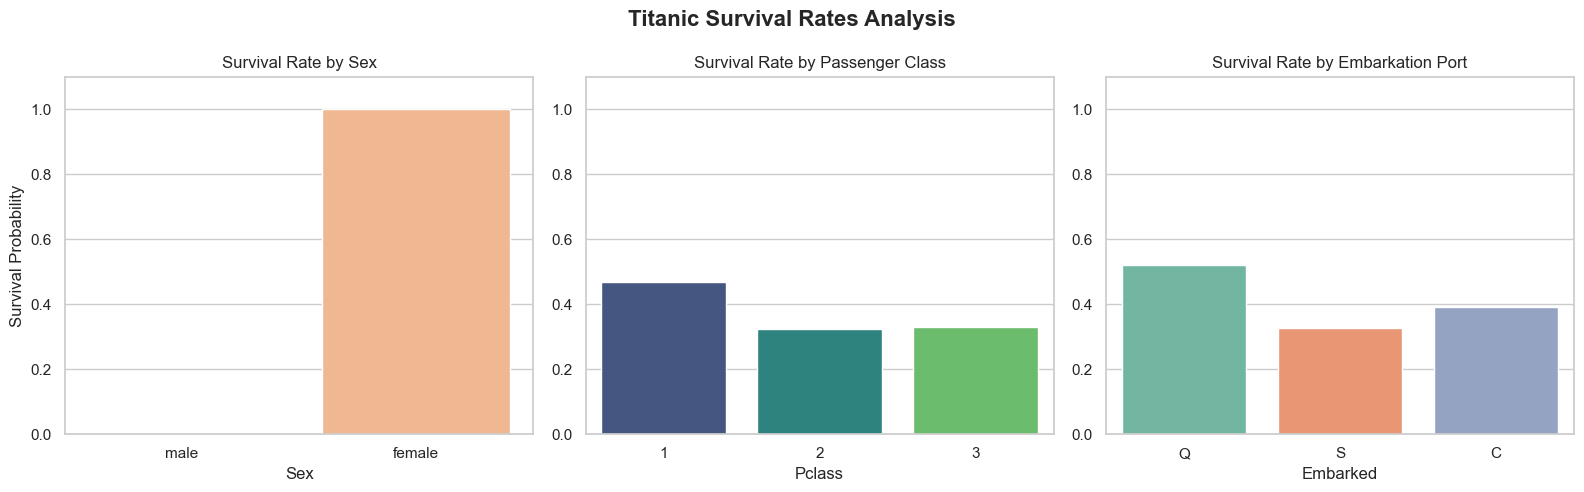

In [110]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Titanic Survival Rates Analysis', fontsize=16, fontweight='bold')

# Chart 1: Survival by Sex
sns.barplot(x='Sex', y='Survived', data=df, ax=axes[0], palette='pastel', errorbar=None)
axes[0].set_title('Survival Rate by Sex', fontsize=12)
axes[0].set_ylabel('Survival Probability')
axes[0].set_ylim(0, 1.1) # Set y-axis to go from 0 to 1 (0% to 100%)

# Chart 2: Survival by Pclass
sns.barplot(x='Pclass', y='Survived', data=df, ax=axes[1], palette='viridis', errorbar=None)
axes[1].set_title('Survival Rate by Passenger Class', fontsize=12)
axes[1].set_ylabel('') # Hide y-label for middle chart to keep it clean
axes[1].set_ylim(0, 1.1)

# Chart 3: Survival by Embarked
sns.barplot(x='Embarked', y='Survived', data=df, ax=axes[2], palette='Set2', errorbar=None)
axes[2].set_title('Survival Rate by Embarkation Port', fontsize=12)
axes[2].set_ylabel('')
axes[2].set_ylim(0, 1.1)

plt.tight_layout()
plt.show()

In [111]:

df_ml = df.copy()

df_ml.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)


df_ml['Age'].fillna(df_ml['Age'].median(), inplace=True)
df_ml['Fare'].fillna(df_ml['Fare'].median(), inplace=True)

df_ml['Embarked'].fillna(df_ml['Embarked'].mode()[0], inplace=True)

df_ml['Sex'] = df_ml['Sex'].map({'female': 0, 'male': 1})
df_ml['Embarked'] = df_ml['Embarked'].map({'C': 0, 'Q': 1, 'S': 2})

In [112]:

X = df_ml.drop('Survived', axis=1)
y = df_ml['Survived']

# Split: 80% for training the model, 20% for evaluating it
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [113]:

print("\nTraining the Logistic Regression model...")

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)



Training the Logistic Regression model...


LogisticRegression(max_iter=1000, random_state=42)

In [114]:
y_pred = lr_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"LOGISTIC REGRESSION ACCURACY: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

LOGISTIC REGRESSION ACCURACY: 100.00%

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84



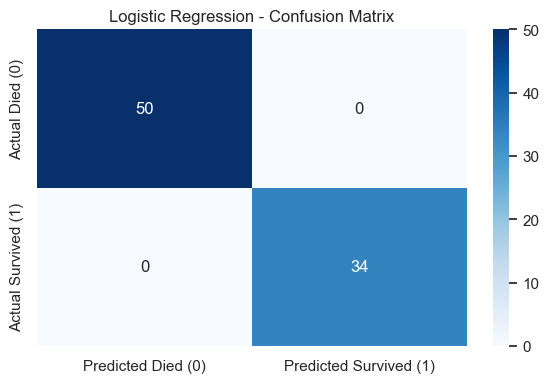

In [115]:
plt.figure(figsize=(6,4))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Predicted Died (0)', 'Predicted Survived (1)'], 
            yticklabels=['Actual Died (0)', 'Actual Survived (1)'])
plt.title('Logistic Regression - Confusion Matrix')
plt.tight_layout()